# 🚗 Vehicle Damage Detection for Insurance
### CNN-based Classification: No Damage | Minor | Moderate | Severe
---

## 📦 Step 1: Libraries Import

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow Version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
GPU Available: []


## 📂 Step 2: Dataset Paths & Config

In [16]:
# ─── APNA PATH YAHAN SET KARO ───
TRAIN_DIR = r"C:\Users\cuty computey\Desktop\Faizan Akram\DL\Project\dataset\train"   # folders: no_damage, minor, moderate, severe
TEST_DIR  = r"C:\Users\cuty computey\Desktop\Faizan Akram\DL\Project\dataset\test"

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 4

print('Config set!')

Config set!


## 🔍 Step 3: Dataset Exploration (EDA)

In [7]:
# Image count per class
print('📊 Training Data Distribution:\n')
train_counts = {}
for cls in os.listdir(TRAIN_DIR):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        train_counts[cls] = count
        print(f'  {cls:15s} → {count} images')

print(f'\n  Total Training Images: {sum(train_counts.values())}')

print('\n📊 Test Data Distribution:\n')
test_counts = {}
for cls in os.listdir(TEST_DIR):
    cls_path = os.path.join(TEST_DIR, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        test_counts[cls] = count
        print(f'  {cls:15s} → {count} images')

print(f'\n  Total Test Images: {sum(test_counts.values())}')

📊 Training Data Distribution:

  minor           → 452 images
  moderate        → 463 images
  no_damage       → 470 images
  severe          → 468 images

  Total Training Images: 1853

📊 Test Data Distribution:

  minor           → 82 images
  moderate        → 75 images
  no_damage       → 100 images
  severe          → 91 images

  Total Test Images: 348


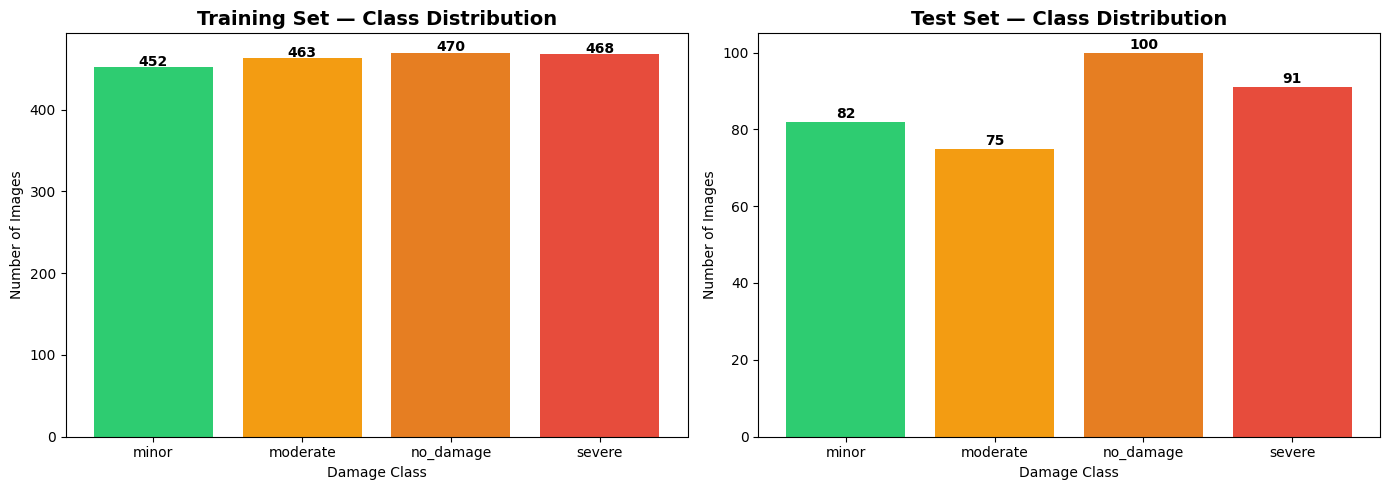

In [8]:
# Bar chart — class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

axes[0].bar(train_counts.keys(), train_counts.values(), color=colors)
axes[0].set_title('Training Set — Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Damage Class')
axes[0].set_ylabel('Number of Images')
for i, (k, v) in enumerate(train_counts.items()):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].bar(test_counts.keys(), test_counts.values(), color=colors)
axes[1].set_title('Test Set — Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Damage Class')
axes[1].set_ylabel('Number of Images')
for i, (k, v) in enumerate(test_counts.items()):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

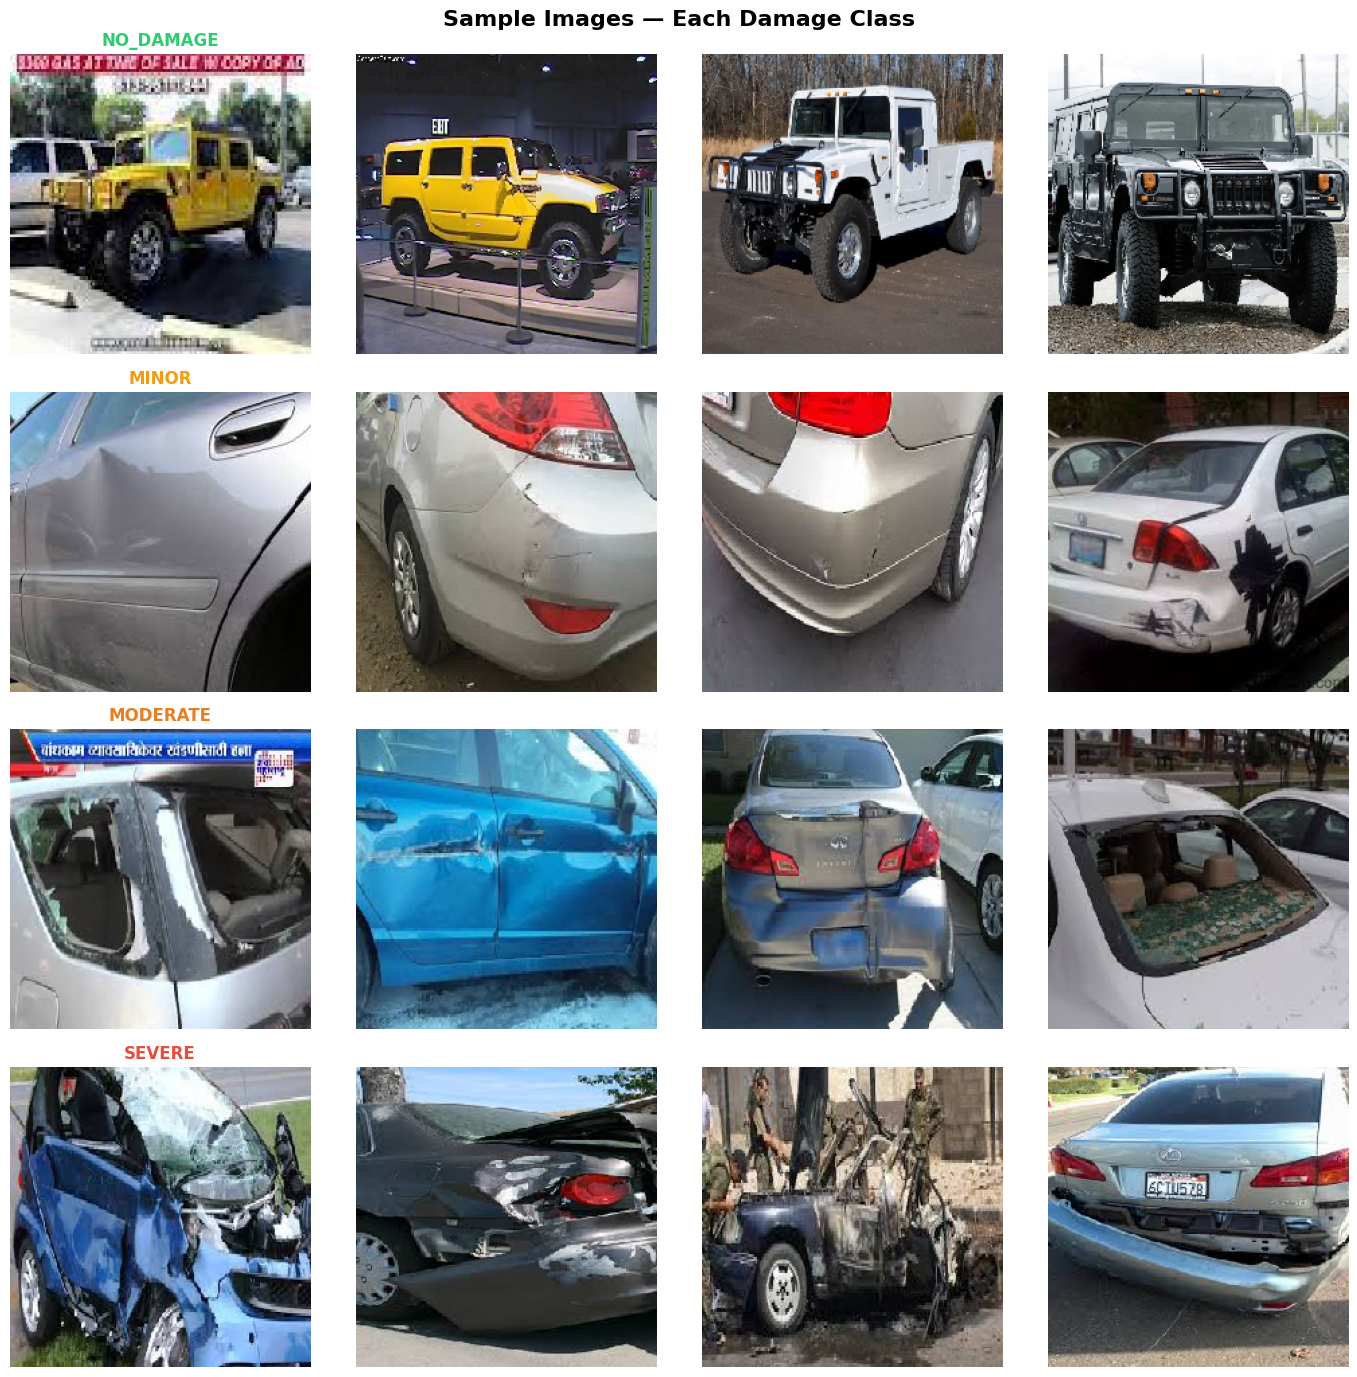

In [9]:
# Sample images from each class
from tensorflow.keras.preprocessing.image import load_img

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Sample Images — Each Damage Class', fontsize=16, fontweight='bold')

label_colors = {'no_damage': '#2ecc71', 'minor': '#f39c12',
                'moderate': '#e67e22', 'severe': '#e74c3c'}

for row, cls in enumerate(['no_damage', 'minor', 'moderate', 'severe']):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images = os.listdir(cls_path)[:4]
    for col, img_name in enumerate(images):
        img = load_img(os.path.join(cls_path, img_name), target_size=IMG_SIZE)
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(cls.upper(), fontsize=12,
                                     fontweight='bold',
                                     color=label_colors[cls])

plt.tight_layout()
plt.show()

## 🔄 Step 4: Data Preprocessing & Augmentation

In [17]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.25,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_labels = list(train_generator.class_indices.keys())
print('Classes:', class_labels)

Found 1853 images belonging to 4 classes.
Found 348 images belonging to 4 classes.
Classes: ['minor', 'moderate', 'no_damage', 'severe']


## 🧠 Step 5: VGG16 Model Build

In [20]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, Model  # ← Model add kiya

# VGG16 base — ImageNet weights, no top layer
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all base layers
base_model.trainable = False
print(f'VGG16 layers: {len(base_model.layers)} (all frozen)')

# Custom classifier head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary()

VGG16 layers: 19 (all frozen)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,89

 Total params: 14,880,452 (56.76 MB)

 Trainable params: 165,252 (645.52 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

## ⚙️ Step 6: Phase 1 — Train Classifier Head (Frozen VGG16)

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_vgg16_phase1.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

print('Phase 1 Training — Frozen VGG16...')
history1 = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=callbacks_p1,
    verbose=1
)

Phase 1 Training — Frozen VGG16...
Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.2683 - loss: 1.8729
Epoch 1: val_accuracy improved from -inf to 0.55460, saving model to best_vgg16_phase1.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 537s 9s/step - accuracy: 0.2688 - loss: 1.8707 - val_accuracy: 0.5546 - val_loss: 1.3086 - learning_rate: 1.0000e-04
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3920 - loss: 1.4166
Epoch 2: val_accuracy improved from 0.55460 to 0.62644, saving model to best_vgg16_phase1.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 515s 9s/step - accuracy: 0.3923 - loss: 1.4159 - val_accuracy: 0.6264 - val_loss: 1.2177 - learning_rate: 1.0000e-04
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4491 - loss: 1.2772
Epoch 3: val_accuracy improved from 0.62644 to 0.67241, saving model to best_vgg16_phase1.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 578s 10s/step - accuracy: 0.4493 - loss: 1.2771 - val_accuracy: 0.6724 - val_loss: 1.1205 - learning_rate: 1.0000e-04
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.4857 - loss: 1.2970
Epoch 4: val_accuracy improved from 0.67241 to 0.68966, saving model to best_vgg16_phase1.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 632s 11s/step - accuracy: 0.4862 - loss: 1.2959 - val_accuracy: 0.6897 - val_loss: 1.0188 - learning_rate: 1.0000e-04
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5258 - loss: 1.1407
Epoch 5: val_accuracy improved from 0.68966 to 0.69253, saving model to best_vgg16_phase1.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 641s 10s/step - accuracy: 0.5256 - loss: 1.1410 - val_accuracy: 0.6925 - val_loss: 0.9056 - learning_rate: 1.0000e-04
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5028 - loss: 1.1708
Epoch 6: val_accuracy improved from 0.69253 to 0.70115, saving model to best_vgg16_phase1.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 583s 10s/step - accuracy: 0.5030 - loss: 1.1702 - val_accuracy: 0.7011 - val_loss: 0.8253 - learning_rate: 1.0000e-04
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5300 - loss: 1.1370
Epoch 7: val_accuracy improved from 0.70115 to 0.70690, saving model to best_vgg16_phase1.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 580s 10s/step - accuracy: 0.5302 - loss: 1.1365 - val_accuracy: 0.7069 - val_loss: 0.7640 - learning_rate: 1.0000e-04
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.5531 - loss: 1.0868 
Epoch 8: val_accuracy did not improve from 0.70690
58/58 ━━━━━━━━━━━━━━━━━━━━ 705s 12s/step - accuracy: 0.5529 - loss: 1.0870 - val_accuracy: 0.6983 - val_loss: 0.7349 - learning_rate: 1.0000e-04
Epoch 9/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5672 - loss: 1.0476
Epoch 9: val_accuracy improved from 0.70690 to 0.71264, saving model to best_vgg16_phase1.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 519s 9s/step - accuracy: 0.5669 - loss: 1.0480 - val_accuracy: 0.7126 - val_loss: 0.7232 - learning_rate: 1.0000e-04
Epoch 10/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5568 - loss: 1.0326
Epoch 10: val_accuracy improved from 0.71264 to 0.72989, saving model to best_vgg16_phase1.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 517s 9s/step - accuracy: 0.5566 - loss: 1.0334 - val_accuracy: 0.7299 - val_loss: 0.7017 - learning_rate: 1.0000e-04
Epoch 11/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5477 - loss: 1.0554
Epoch 11: val_accuracy did not improve from 0.72989
58/58 ━━━━━━━━━━━━━━━━━━━━ 533s 9s/step - accuracy: 0.5478 - loss: 1.0552 - val_accuracy: 0.7126 - val_loss: 0.7007 - learning_rate: 1.0000e-04
Epoch 12/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5752 - loss: 1.0230
Epoch 12: val_accuracy did not improve from 0.72989
58/58 ━━━━━━━━━━━━━━━━━━━━ 503s 9s/step - accuracy: 0.5752 - loss: 1.0231 - val_accuracy: 0.7184 - val_loss: 0.6998 - learning_rate: 1.0000e-04
Epoch 13/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5741 - loss: 1.0300
Epoch 13: val_accuracy did not improve from 0.72989
58/58 ━━━━━━━━━━━━━━━━━━━━ 522s 9s/step - accuracy: 0.5740 - loss: 1.0300 - val_accuracy: 0.7213 - val_loss: 0.6984 - learning_rate: 1.0000e-04
Epoch 14/20
58/5

## 🏋️ Step 7: Phase 2 — Fine-Tuning (Unfreeze Last 4 Layers)

In [22]:
# Unfreeze last 4 VGG16 layers
for layer in base_model.layers[-4:]:
    layer.trainable = True

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f'Trainable layers after unfreeze: {trainable_count}')

# Very small LR for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_vgg16_final.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-8, verbose=1)
]

print('Phase 2 Fine-tuning...')
history2 = model.fit(
    train_generator,
    epochs=7,
    validation_data=test_generator,
    callbacks=callbacks_p2,
    verbose=1
)

Trainable layers after unfreeze: 11
Phase 2 Fine-tuning...
Epoch 1/7
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.5970 - loss: 0.9546
Epoch 1: val_accuracy improved from -inf to 0.73276, saving model to best_vgg16_final.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 646s 11s/step - accuracy: 0.5969 - loss: 0.9548 - val_accuracy: 0.7328 - val_loss: 0.7117 - learning_rate: 1.0000e-05
Epoch 2/7
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.5890 - loss: 0.9824
Epoch 2: val_accuracy improved from 0.73276 to 0.73563, saving model to best_vgg16_final.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 646s 11s/step - accuracy: 0.5891 - loss: 0.9818 - val_accuracy: 0.7356 - val_loss: 0.6888 - learning_rate: 1.0000e-05
Epoch 3/7
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6174 - loss: 0.8960
Epoch 3: val_accuracy did not improve from 0.73563
58/58 ━━━━━━━━━━━━━━━━━━━━ 637s 11s/step - accuracy: 0.6176 - loss: 0.8958 - val_accuracy: 0.7270 - val_loss: 0.7059 - learning_rate: 1.0000e-05
Epoch 4/7
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6324 - loss: 0.8591
Epoch 4: val_accuracy did not improve from 0.73563
58/58 ━━━━━━━━━━━━━━━━━━━━ 664s 11s/step - accuracy: 0.6327 - loss: 0.8592 - val_accuracy: 0.7356 - val_loss: 0.6569 - learning_rate: 1.0000e-05
Epoch 5/7
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6493 - loss: 0.8106
Epoch 5: val_accuracy improved from 0.73563 to 0.74713, saving model to best_vgg16_final.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 662s 11s/step - accuracy: 0.6492 - loss: 0.8113 - val_accuracy: 0.7471 - val_loss: 0.6592 - learning_rate: 1.0000e-05
Epoch 6/7
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6478 - loss: 0.8284
Epoch 6: val_accuracy did not improve from 0.74713
58/58 ━━━━━━━━━━━━━━━━━━━━ 645s 11s/step - accuracy: 0.6479 - loss: 0.8287 - val_accuracy: 0.7356 - val_loss: 0.6742 - learning_rate: 1.0000e-05
Epoch 7/7
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6448 - loss: 0.8497
Epoch 7: val_accuracy improved from 0.74713 to 0.75287, saving model to best_vgg16_final.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 643s 11s/step - accuracy: 0.6449 - loss: 0.8497 - val_accuracy: 0.7529 - val_loss: 0.5967 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 7.


## 📈 Step 8: Training Curves

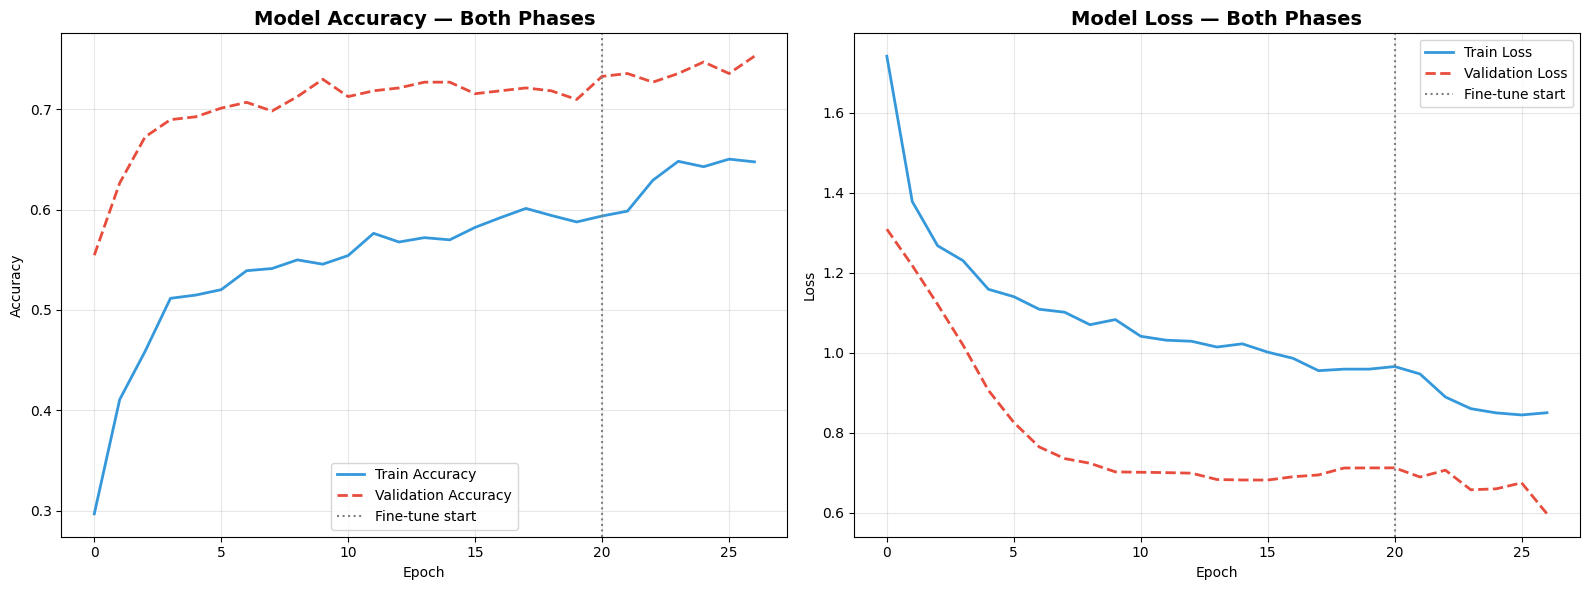

In [23]:
# Combine both histories
acc     = history1.history['accuracy']     + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss    = history1.history['loss']         + history2.history['loss']
val_loss= history1.history['val_loss']     + history2.history['val_loss']

phase1_end = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
axes[0].plot(acc,     label='Train Accuracy',      color='#3498db', linewidth=2)
axes[0].plot(val_acc, label='Validation Accuracy', color='#e74c3c', linewidth=2, linestyle='--')
axes[0].axvline(x=phase1_end, color='gray', linestyle=':', linewidth=1.5, label='Fine-tune start')
axes[0].set_title('Model Accuracy — Both Phases', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(loss,     label='Train Loss',      color='#3498db', linewidth=2)
axes[1].plot(val_loss, label='Validation Loss', color='#e74c3c', linewidth=2, linestyle='--')
axes[1].axvline(x=phase1_end, color='gray', linestyle=':', linewidth=1.5, label='Fine-tune start')
axes[1].set_title('Model Loss — Both Phases', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vgg16_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Step 9: Model Evaluation

In [24]:
# Overall accuracy & loss on test set
test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)
print('=' * 40)
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_accuracy * 100:.2f}%')
print('=' * 40)

  Test Loss     : 0.5967
  Test Accuracy : 75.29%


In [25]:
# Predictions
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())
print('\nClass Labels:', class_labels)

11/11 ━━━━━━━━━━━━━━━━━━━━ 78s 7s/step

Class Labels: ['minor', 'moderate', 'no_damage', 'severe']


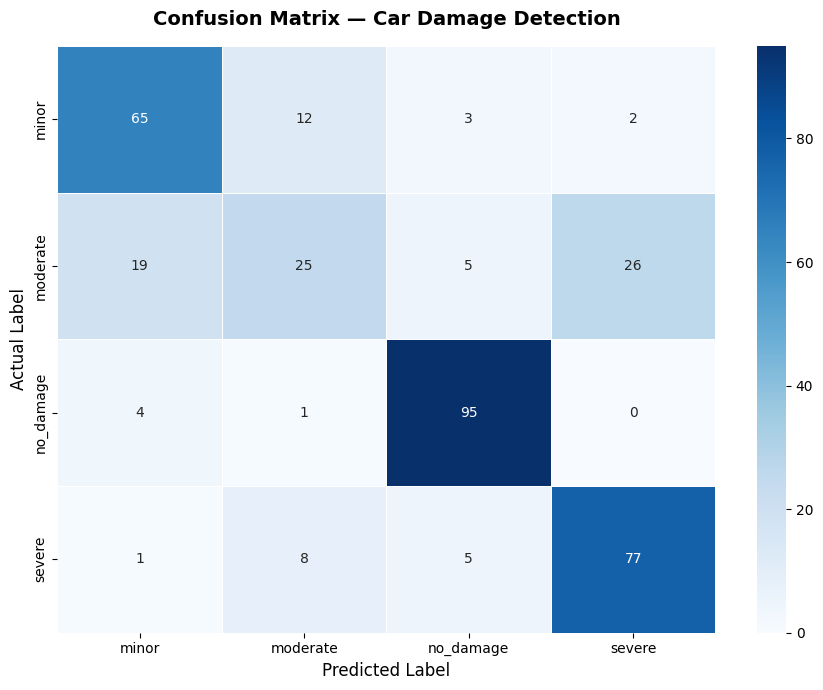

Confusion matrix saved!


In [26]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5
)
plt.title('Confusion Matrix — Car Damage Detection', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved!')

In [27]:
# Classification Report — Precision, Recall, F1
print('\n📋 Classification Report:\n')
print(classification_report(y_true, y_pred, target_names=class_labels))


📋 Classification Report:

              precision    recall  f1-score   support

       minor       0.73      0.79      0.76        82
    moderate       0.54      0.33      0.41        75
   no_damage       0.88      0.95      0.91       100
      severe       0.73      0.85      0.79        91

    accuracy                           0.75       348
   macro avg       0.72      0.73      0.72       348
weighted avg       0.73      0.75      0.74       348



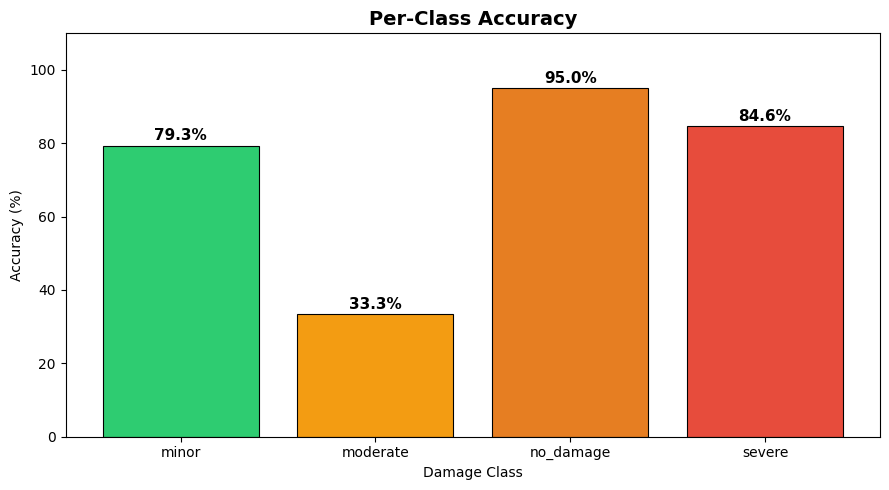

In [28]:
# Per-class accuracy bar chart
per_class_acc = cm.diagonal() / cm.sum(axis=1)

colors_bar = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
plt.figure(figsize=(9, 5))
bars = plt.bar(class_labels, per_class_acc * 100, color=colors_bar, edgecolor='black', linewidth=0.8)
plt.title('Per-Class Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.xlabel('Damage Class')
plt.ylim(0, 110)

for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{acc*100:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔮 Step 10: Predict on a Single Image

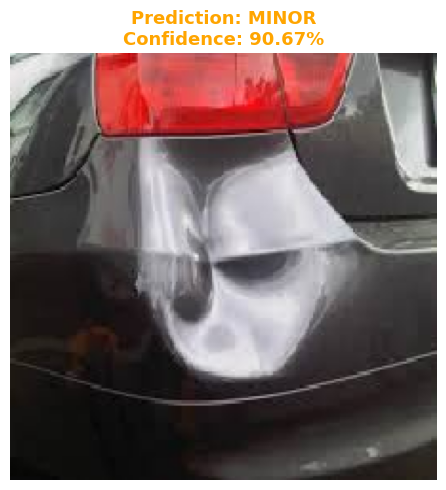


📊 All Class Probabilities:
  minor       :  90.67%  ███████████████████████████
  moderate    :   9.15%  ██
  no_damage   :   0.01%  
  severe      :   0.17%  


('minor', np.float32(90.66968))

In [45]:
from tensorflow.keras.preprocessing import image as keras_image

img_path = r"C:\Users\cuty computey\Desktop\Faizan Akram\DL\Project\0012.JPEG"  # apna path daalo

def predict_damage(img_path, model, class_names):
    img = keras_image.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array, verbose=0)[0]
    pred_class = class_names[np.argmax(preds)]
    confidence = np.max(preds) * 100

    # Display
    plt.figure(figsize=(6, 5))
    plt.imshow(img)
    plt.axis('off')

    color_map = {'no_damage': 'green', 'minor': 'orange',
                 'moderate': 'darkorange', 'severe': 'red'}

    plt.title(f'Prediction: {pred_class.upper()}\nConfidence: {confidence:.2f}%',
              fontsize=13, fontweight='bold',
              color=color_map.get(pred_class, 'black'))
    plt.tight_layout()
    plt.show()

    print('\n📊 All Class Probabilities:')
    for cls, prob in zip(class_names, preds):
        bar = '█' * int(prob * 30)
        print(f'  {cls:12s}: {prob*100:6.2f}%  {bar}')

    return pred_class, confidence

# ─── TEST KARO ───
predict_damage(img_path, model, class_labels)

## 💾 Step 11: Save the Model

In [46]:
model.save('car_damage_model_final.h5')
print('✅ Model saved as car_damage_model_final.h5')

# Load it back anytime:
# from tensorflow.keras.models import load_model
# model = load_model('car_damage_model_final.h5')

✅ Model saved as car_damage_model_final.h5
